In [1]:
# ------------------------------------------------------------
# Notebook 02 — Feature Engineering (Vibe Coding Style)
# BiofilmAI — Gene Expression → Biofilm Prediction
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="deep")


In [2]:
# ------------------------------------------------------------
# Step 1: Load ML-ready table from Notebook 01
# ------------------------------------------------------------

df = pd.read_csv("../data/gene_expression/biofilm_ml_features.csv")
print("Loaded:", df.shape)
df.head()


Loaded: (7563, 28)


,id,gene_symbol,biofilm_logFC,log_CPM,deseq.p-value,biofilm_padj,edger.p.value,edger.adj.p.value,X3225B2.norm,X3225B3.norm,...,WTB4.raw,WTB6.raw,log2FoldChange_norm,planktonic_logFC,planktonic_padj,biofilm_abs_logFC,planktonic_abs_logFC,biofilm_significant,planktonic_significant,biofilm_label
0,PA14_22460,PA14_22460,4.345,7.733,2.000000e-71,1.200000e-67,4.600000e-80,1.400000e-76,1686,1573,...,60,73,4.345,4.044,2.400000e-99,4.345,4.044,1,1,1
1,PA14_22450,ppiA,4.151,7.630,1.000000e-66,3.000000e-63,2.400000e-85,1.400000e-81,1574,1537,...,62,103,4.151,3.982,9.800000e-124,4.151,3.982,1,1,1
2,PA14_22470,PA14_22470,3.929,9.077,8.800000e-66,1.700000e-62,1.800000e-75,3.500000e-72,4458,3785,...,179,313,3.929,3.617,4.900000e-133,3.929,3.617,1,1,1
3,PA14_22440,bapA,3.773,8.996,3.000000e-62,4.400000e-59,1.100000e-73,1.600000e-70,3877,3928,...,222,285,3.773,3.418,3.000000e-91,3.773,3.418,1,1,1
4,PA14_27070,PA14_27070,3.263,9.016,1.400000e-49,1.600000e-46,2.100000e-53,2.500000e-50,4260,3546,...,292,531,3.263,3.031,1.800000e-103,3.263,3.031,1,1,1


In [3]:
# ------------------------------------------------------------
# Step 2: Interaction features
# ------------------------------------------------------------

df["logFC_interaction"] = df["biofilm_logFC"] * df["planktonic_logFC"]
df["abs_logFC_interaction"] = df["biofilm_abs_logFC"] * df["planktonic_abs_logFC"]


In [4]:
# ------------------------------------------------------------
# Step 3: Difference features
# ------------------------------------------------------------

df["logFC_difference"] = df["biofilm_logFC"] - df["planktonic_logFC"]
df["abs_logFC_difference"] = df["biofilm_abs_logFC"] - df["planktonic_abs_logFC"]


In [5]:
# ------------------------------------------------------------
# Step 4: Ratio features
# ------------------------------------------------------------

df["logFC_ratio"] = df["biofilm_logFC"] / (df["planktonic_logFC"] + 1e-6)
df["abs_logFC_ratio"] = df["biofilm_abs_logFC"] / (df["planktonic_abs_logFC"] + 1e-6)


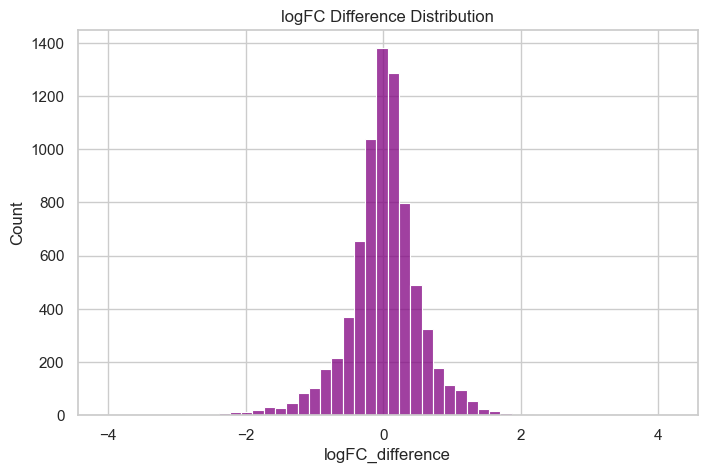

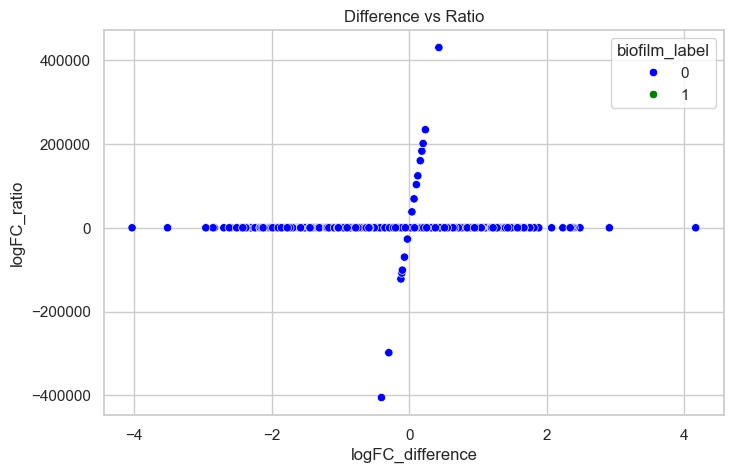

In [6]:
# ------------------------------------------------------------
# Step 5: Visual intuition checks
# ------------------------------------------------------------

plt.figure(figsize=(8,5))
sns.histplot(df["logFC_difference"], bins=50, color="purple")
plt.title("logFC Difference Distribution")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="logFC_difference",
    y="logFC_ratio",
    hue="biofilm_label",
    palette={0:"blue", 1:"green"}
)
plt.title("Difference vs Ratio")
plt.show()


In [7]:
# ------------------------------------------------------------
# Step 6: Save final ML feature table
# ------------------------------------------------------------

df.to_csv("../data/gene_expression/biofilm_ml_features_final.csv", index=False)
print("Saved final ML feature table.")


Saved final ML feature table.


In [8]:
# ------------------------------------------------------------
# Step 7: Summary (Vibe Coding narrative)
# ------------------------------------------------------------

print("""
Feature engineering complete.

This notebook:
- loaded ML-ready table from Notebook 01
- created interaction features
- created difference features
- created ratio features
- generated visual intuition checks
- saved final ML feature table

Ready for Notebook 03 — Model Training.
""")



Feature engineering complete.

This notebook:
- loaded ML-ready table from Notebook 01
- created interaction features
- created difference features
- created ratio features
- generated visual intuition checks
- saved final ML feature table

Ready for Notebook 03 — Model Training.



In [9]:
# ------------------------------------------------------------
# Add interaction, difference, and ratio features
# ------------------------------------------------------------

# Interaction terms
df["logFC_interaction"] = df["biofilm_logFC"] * df["planktonic_logFC"]
df["abs_logFC_interaction"] = df["biofilm_abs_logFC"] * df["planktonic_abs_logFC"]

# Differences
df["logFC_difference"] = df["biofilm_logFC"] - df["planktonic_logFC"]
df["abs_logFC_difference"] = df["biofilm_abs_logFC"] - df["planktonic_abs_logFC"]

# Ratios (avoid division by zero)
df["logFC_ratio"] = df["biofilm_logFC"] / (df["planktonic_logFC"] + 1e-9)
df["abs_logFC_ratio"] = df["biofilm_abs_logFC"] / (df["planktonic_abs_logFC"] + 1e-9)

print("Added interaction, difference, and ratio features.")
df.head()


Added interaction, difference, and ratio features.


,id,gene_symbol,biofilm_logFC,log_CPM,deseq.p-value,biofilm_padj,edger.p.value,edger.adj.p.value,X3225B2.norm,X3225B3.norm,...,planktonic_abs_logFC,biofilm_significant,planktonic_significant,biofilm_label,logFC_interaction,abs_logFC_interaction,logFC_difference,abs_logFC_difference,logFC_ratio,abs_logFC_ratio
0,PA14_22460,PA14_22460,4.345,7.733,2.000000e-71,1.200000e-67,4.600000e-80,1.400000e-76,1686,1573,...,4.044,1,1,1,17.571180,17.571180,0.301,0.301,1.074431,1.074431
1,PA14_22450,ppiA,4.151,7.630,1.000000e-66,3.000000e-63,2.400000e-85,1.400000e-81,1574,1537,...,3.982,1,1,1,16.529282,16.529282,0.169,0.169,1.042441,1.042441
2,PA14_22470,PA14_22470,3.929,9.077,8.800000e-66,1.700000e-62,1.800000e-75,3.500000e-72,4458,3785,...,3.617,1,1,1,14.211193,14.211193,0.312,0.312,1.086259,1.086259
3,PA14_22440,bapA,3.773,8.996,3.000000e-62,4.400000e-59,1.100000e-73,1.600000e-70,3877,3928,...,3.418,1,1,1,12.896114,12.896114,0.355,0.355,1.103862,1.103862
4,PA14_27070,PA14_27070,3.263,9.016,1.400000e-49,1.600000e-46,2.100000e-53,2.500000e-50,4260,3546,...,3.031,1,1,1,9.890153,9.890153,0.232,0.232,1.076542,1.076542


In [10]:
df.to_csv("../data/gene_expression/biofilm_ml_features.csv", index=False)
print("Updated feature table saved.")


Updated feature table saved.
